In [ ]:
import pandas as pd
import numpy as np
import re

INPUT_FILE = "/content/DOC-20260118-WA0003.xlsx"
SHEET_NAME = "urine"
EPS = 1e-9
NORMALIZATION = "zscore"   # or "minmax"

def standardize_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

def detect_u6_column(columns):
    u6 = [c for c in columns if re.search(r"u6.*ctmean", c)]
    if len(u6) != 1:
        raise ValueError(f"Expected exactly one U6 column, found: {u6}")
    return u6[0]

# ================= LOAD =================
df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME)
df = standardize_columns(df)

u6_col = detect_u6_column(df.columns)

# ================= AUTO-DETECT miRNAs =================
ctmean_cols = [c for c in df.columns if c.endswith("_ctmean")]
mirna_cols = [c for c in ctmean_cols if c != u6_col]

# ================= ΔCt =================
delta_ct = df[mirna_cols].subtract(df[u6_col], axis=0)

# Rename → *_deltact
delta_ct.columns = [c.replace("_ctmean", "_deltact") for c in delta_ct.columns]

# ================= NORMALIZATION =================
if NORMALIZATION == "zscore":
    delta_ct = (delta_ct - delta_ct.mean()) / (delta_ct.std(ddof=0) + EPS)
else:
    delta_ct = (delta_ct - delta_ct.min()) / (delta_ct.max() - delta_ct.min() + EPS)

# ================= MERGE BACK =================
preprocessed_df = pd.concat([df, delta_ct], axis=1)

# print(preprocessed_df)
preprocessed_df.head()

,patient_id,groups,urn_21-5p_ctmean,urn_19b-3p_ctmean,urn_mir-375-3p_ctmean,urn_101-3p_ctmean,urn_let-7c_ctmean,urn_u6_ctmean,urn_21-5p_deltact,urn_19b-3p_deltact,urn_mir-375-3p_deltact,urn_101-3p_deltact,urn_let-7c_deltact
0,pca.apr.04,PCA,23.8650,22.3680,25.7080,25.5300,21.9600,21.694,-0.796686,-1.069666,-1.260136,-0.716961,-0.141888
1,pca.jn.04,BPH,30.4445,28.9920,30.1990,25.9690,21.9820,21.537,1.087496,0.981615,0.184553,-0.522419,-0.070819
2,Pca.mr. 09,PCA,27.8530,25.6360,30.2910,29.8575,25.7175,27.939,-1.427964,-1.970222,-1.776718,-1.342859,-1.129513
3,pca.may.08,PCA,34.7390,30.4955,31.7075,31.1580,24.8135,22.901,1.907150,1.023815,0.229466,0.726113,0.511829
4,pca.may.02,PCA,30.7520,29.7270,31.0640,30.8965,24.4365,20.491,1.466067,1.520376,0.778528,1.427413,1.319001


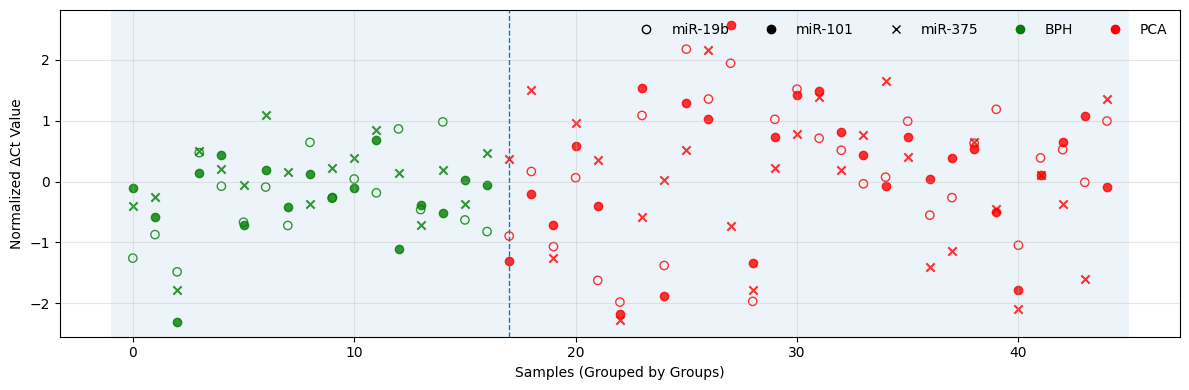

In [ ]:
plt.figure(figsize=(12, 4))

# Reorder by groups (important)
plot_df = preprocessed_df.sort_values("groups").reset_index(drop=True)
plot_df["sample"] = np.arange(len(plot_df))

# Determine split point
bph_count = (plot_df["groups"].str.upper() == "BPH").sum()

# Background shading
plt.axvspan(-1, bph_count, alpha=0.08)
plt.axvspan(bph_count, len(plot_df), alpha=0.08)

color_map = {"BPH": "green", "PCA": "red"}

# ---- miR-19b (open circle)
for grp in ["BPH", "PCA"]:
    s = plot_df[plot_df["groups"].str.upper() == grp]
    plt.scatter(
        s["sample"],
        s["urn_19b-3p_deltact"],
        marker="o",
        facecolors="none",
        edgecolors=color_map[grp],
        alpha=0.8
    )

# ---- miR-101 (filled circle)
for grp in ["BPH", "PCA"]:
    s = plot_df[plot_df["groups"].str.upper() == grp]
    plt.scatter(
        s["sample"],
        s["urn_101-3p_deltact"],
        marker="o",
        color=color_map[grp],
        alpha=0.8
    )

# ---- miR-375 (cross)
for grp in ["BPH", "PCA"]:
    s = plot_df[plot_df["groups"].str.upper() == grp]
    plt.scatter(
        s["sample"],
        s["urn_mir-375-3p_deltact"],
        marker="x",
        color=color_map[grp],
        alpha=0.8
    )

# Vertical separator
plt.axvline(bph_count, linestyle="--", linewidth=1)

plt.xlabel("Samples (Grouped by Groups)")
plt.ylabel("Normalized ΔCt Value")

# Minimal custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='black', markerfacecolor='none', linestyle='None', label='miR-19b'),
    Line2D([0],[0], marker='o', color='black', linestyle='None', label='miR-101'),
    Line2D([0],[0], marker='x', color='black', linestyle='None', label='miR-375'),
    Line2D([0],[0], marker='o', color='green', linestyle='None', label='BPH'),
    Line2D([0],[0], marker='o', color='red', linestyle='None', label='PCA')
]

plt.legend(handles=legend_elements, ncol=5, frameon=False)
plt.tight_layout()
plt.grid(alpha=.3)
plt.show()

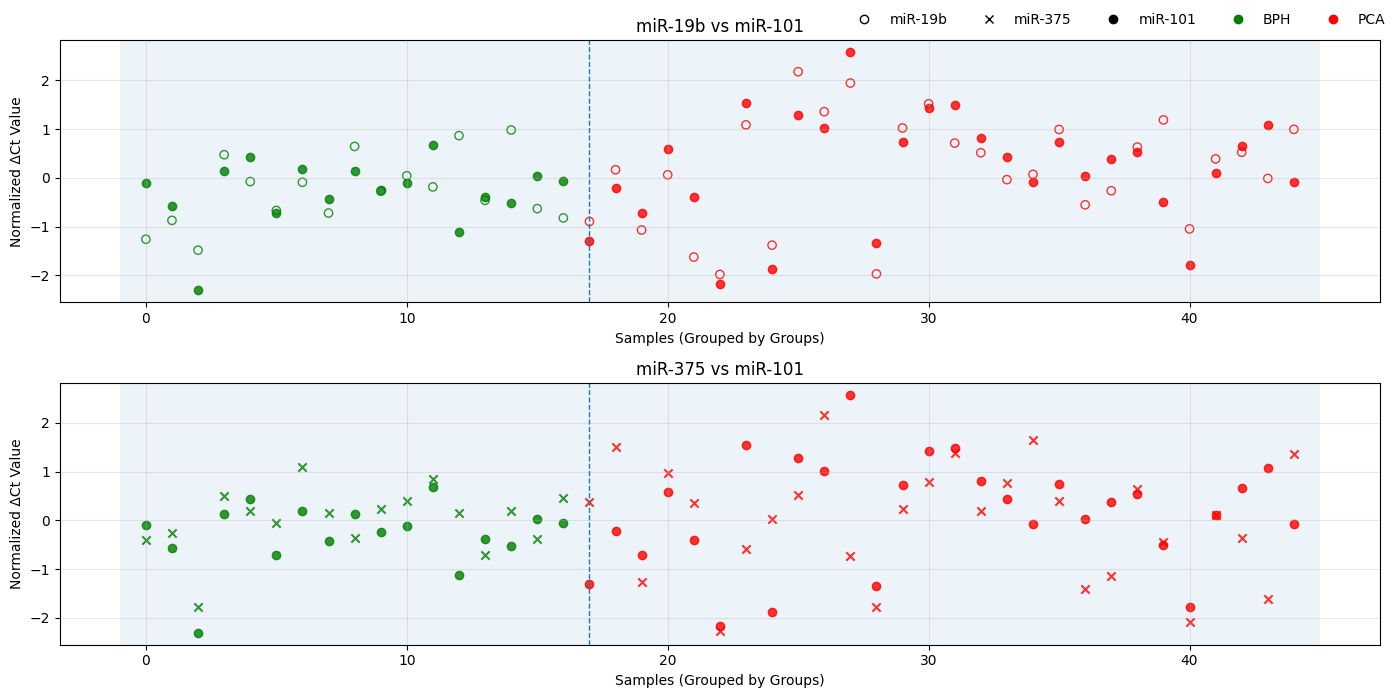

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Sort once (critical)
plot_df = preprocessed_df.sort_values("groups").reset_index(drop=True)
plot_df["sample"] = np.arange(len(plot_df))

bph_count = (plot_df["groups"].str.upper() == "BPH").sum()
color_map = {"BPH": "green", "PCA": "red"}

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharey=True)

# =========================================================
# SUBPLOT 1 → 19b & 101
# =========================================================
ax = axes[0]

ax.axvspan(-1, bph_count, alpha=0.08)
ax.axvspan(bph_count, len(plot_df), alpha=0.08)
ax.axvline(bph_count, linestyle="--", linewidth=1)

for grp in ["BPH", "PCA"]:
    s = plot_df[plot_df["groups"].str.upper() == grp]

    ax.scatter(
        s["sample"], s["urn_19b-3p_deltact"],
        marker="o", facecolors="none",
        edgecolors=color_map[grp], alpha=0.8
    )

    ax.scatter(
        s["sample"], s["urn_101-3p_deltact"],
        marker="o", color=color_map[grp], alpha=0.8
    )

ax.set_title("miR-19b vs miR-101")
ax.set_xlabel("Samples (Grouped by Groups)")
ax.set_ylabel("Normalized ΔCt Value")
ax.grid(alpha=0.3)

# =========================================================
# SUBPLOT 2 → 375 & 101
# =========================================================
ax = axes[1]

ax.axvspan(-1, bph_count, alpha=0.08)
ax.axvspan(bph_count, len(plot_df), alpha=0.08)
ax.axvline(bph_count, linestyle="--", linewidth=1)

for grp in ["BPH", "PCA"]:
    s = plot_df[plot_df["groups"].str.upper() == grp]

    ax.scatter(
        s["sample"], s["urn_mir-375-3p_deltact"],
        marker="x", color=color_map[grp], alpha=0.8
    )

    ax.scatter(
        s["sample"], s["urn_101-3p_deltact"],
        marker="o", color=color_map[grp], alpha=0.8
    )

ax.set_title("miR-375 vs miR-101")
ax.set_xlabel("Samples (Grouped by Groups)")
ax.set_ylabel("Normalized ΔCt Value")
ax.grid(alpha=0.3)

# =========================================================
# Global Legend (unchanged style)
# =========================================================
legend_elements = [
    Line2D([0],[0], marker='o', color='black', markerfacecolor='none',
           linestyle='None', label='miR-19b'),
    Line2D([0],[0], marker='x', color='black',
           linestyle='None', label='miR-375'),
    Line2D([0],[0], marker='o', color='black',
           linestyle='None', label='miR-101'),
    Line2D([0],[0], marker='o', color='green',
           linestyle='None', label='BPH'),
    Line2D([0],[0], marker='o', color='red',
           linestyle='None', label='PCA')
]

fig.legend(handles=legend_elements, ncol=5, frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import zscore
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression

# Copy processed dataframe
z_df = preprocessed_df.copy()

# ΔCt feature columns
z_cols = [
    "urn_19b-3p_deltact",
    "urn_101-3p_deltact",
    "urn_mir-375-3p_deltact"
]

# Z-score normalization
z_df[z_cols] = z_df[z_cols].apply(zscore)

# Coordination features
z_df["coord_101_19b"] = np.abs(
    z_df["urn_101-3p_deltact"] - z_df["urn_19b-3p_deltact"]
)

z_df["coord_101_375"] = np.abs(
    z_df["urn_101-3p_deltact"] - z_df["urn_mir-375-3p_deltact"]
)

# Feature sets
X_raw = z_df[z_cols]
X_coord = z_df[["coord_101_19b", "coord_101_375"]]

# Target
y = (z_df["groups"].str.upper() == "PCA").astype(int)

model = LogisticRegression(max_iter=1000)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Cross-validated metrics
raw_scores = cross_validate(model, X_raw, y, cv=5, scoring=scoring)
coord_scores = cross_validate(model, X_coord, y, cv=5, scoring=scoring)

print("===== RAW FEATURES =====")
for metric in scoring:
    print(metric, ":", raw_scores[f"test_{metric}"].mean())

print("\n===== COORDINATION FEATURES =====")
for metric in scoring:
    print(metric, ":", coord_scores[f"test_{metric}"].mean())

===== RAW FEATURES =====
accuracy : 0.5111111111111111
precision : 0.5726190476190476
recall : 0.7
f1 : 0.6061538461538462
roc_auc : 0.571111111111111

===== COORDINATION FEATURES =====
accuracy : 0.5777777777777777
precision : 0.6279365079365078
recall : 0.8333333333333334
f1 : 0.7024975024975026
roc_auc : 0.6233333333333333


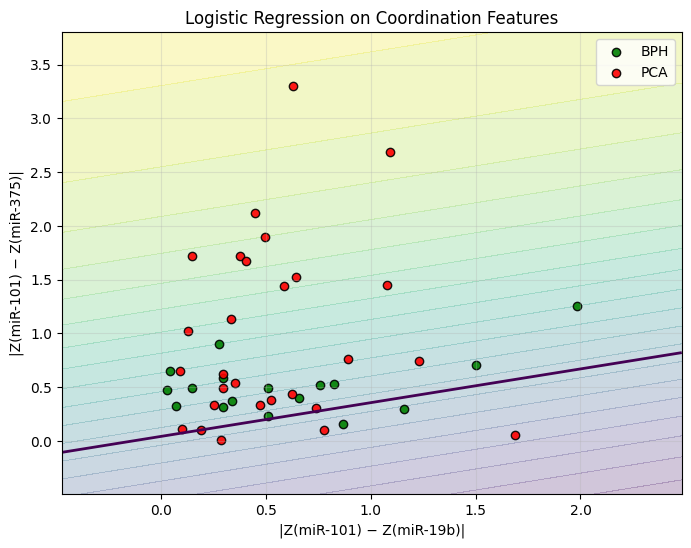

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.linear_model import LogisticRegression

# ================= PREPARE DATA =================
plot_df = preprocessed_df.copy()

z_cols = [
    "urn_19b-3p_deltact",
    "urn_101-3p_deltact",
    "urn_mir-375-3p_deltact"
]

# Z-score normalization
plot_df[z_cols] = plot_df[z_cols].apply(zscore)

# Coordination features
plot_df["coord_101_19b"] = np.abs(
    plot_df["urn_101-3p_deltact"] - plot_df["urn_19b-3p_deltact"]
)

plot_df["coord_101_375"] = np.abs(
    plot_df["urn_101-3p_deltact"] - plot_df["urn_mir-375-3p_deltact"]
)

X = plot_df[["coord_101_19b", "coord_101_375"]].values
y = (plot_df["groups"].str.upper() == "PCA").astype(int).values

# ================= TRAIN MODEL =================
model = LogisticRegression()
model.fit(X, y)

# ================= DECISION SURFACE =================
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

# ================= PLOT =================
plt.figure(figsize=(8, 6))

# Background probability gradient
plt.contourf(xx, yy, probs, levels=20, alpha=0.25)

# Decision boundary (p = 0.5)
plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)

color_map = {"BPH": "green", "PCA": "red"}

for grp in ["BPH", "PCA"]:
    s = plot_df[plot_df["groups"].str.upper() == grp]

    plt.scatter(
        s["coord_101_19b"],
        s["coord_101_375"],
        c=color_map[grp],
        label=grp,
        edgecolors="black",
        alpha=0.9
    )

plt.xlabel("|Z(miR-101) − Z(miR-19b)|")
plt.ylabel("|Z(miR-101) − Z(miR-375)|")
plt.title("Logistic Regression on Coordination Features")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

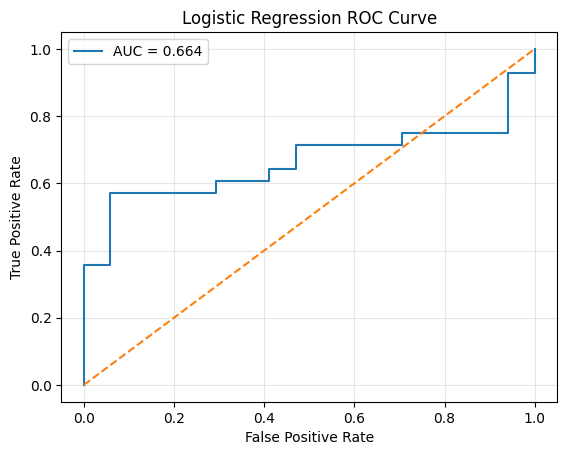

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Prepare data
plot_df = preprocessed_df.copy()

z_cols = [
    "urn_19b-3p_deltact",
    "urn_101-3p_deltact",
    "urn_mir-375-3p_deltact"
]

plot_df[z_cols] = plot_df[z_cols].apply(zscore)

X = plot_df[z_cols]
y = (plot_df["groups"].str.upper() == "PCA").astype(int)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Predicted probabilities
y_prob = model.predict_proba(X)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import numpy as np
from scipy.stats import zscore
from sklearn.model_selection import cross_validate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# ================= DATA =================
df = preprocessed_df.copy()

features = [
    "urn_19b-3p_deltact",
    "urn_101-3p_deltact",
    "urn_mir-375-3p_deltact"
]

df[features] = df[features].apply(zscore)

X = df[features]
y = (df["groups"].str.upper() == "PCA").astype(int)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

models = {
    "Logistic Regression (baseline)": SVC(kernel="linear", probability=True),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# ================= EVALUATION =================
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=5, scoring=scoring)

    print("\n", name)
    for metric in scoring:
        print(metric, ":", scores[f"test_{metric}"].mean())


 Logistic Regression (baseline)
accuracy : 0.5777777777777778
precision : 0.5111111111111111
recall : 0.8
f1 : 0.622857142857143
roc_auc : 0.44666666666666666

 SVM (RBF)
accuracy : 0.6888888888888889
precision : 0.7683333333333333
recall : 0.7466666666666666
f1 : 0.7307292707292706
roc_auc : 0.8922222222222222

 Random Forest
accuracy : 0.6222222222222221
precision : 0.7044444444444444
recall : 0.7133333333333333
f1 : 0.6797402597402598
roc_auc : 0.7644444444444445

 Gradient Boosting
accuracy : 0.6444444444444445
precision : 0.7290476190476192
recall : 0.6733333333333332
f1 : 0.6834032634032634
roc_auc : 0.6672222222222224

 KNN
accuracy : 0.6666666666666666
precision : 0.7428571428571429
recall : 0.6733333333333333
f1 : 0.6838095238095238
roc_auc : 0.7738888888888888


# new

In [ ]:
import pandas as pd

# Example: load dataset
# df = pd.read_excel("your_file.xlsx")
# or
# df = pd.read_csv("your_file.csv")

# ------------------------------------------------------------
# 1. Standardize column names
# ------------------------------------------------------------
def standardize_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

df = standardize_columns(df)

# ------------------------------------------------------------
# 2. Identify CtMean columns
# ------------------------------------------------------------
ctmean_cols = [c for c in df.columns if c.endswith("_ctmean")]

# Identify U6 column safely
u6_col = [c for c in ctmean_cols if "u6" in c][0]

# miRNA columns (exclude U6)
mirna_cols = [c for c in ctmean_cols if c != u6_col]

print("CtMean Columns:", ctmean_cols)
print("U6 Column:", u6_col)
print("miRNA Columns:", mirna_cols)

# ------------------------------------------------------------
# 3. Add label column (BPH = 0, PCA = 1)
# ------------------------------------------------------------
df["label"] = df["groups"].str.strip().str.lower().map({
    "bph": 0,
    "pca": 1
})

# ------------------------------------------------------------
# 4. Print processed dataframe
# ------------------------------------------------------------
print("\nProcessed DataFrame:")
df.head()

CtMean Columns: ['urn_21-5p_ctmean', 'urn_19b-3p_ctmean', 'urn_mir-375-3p_ctmean', 'urn_101-3p_ctmean', 'urn_let-7c_ctmean', 'urn_u6_ctmean']
U6 Column: urn_u6_ctmean
miRNA Columns: ['urn_21-5p_ctmean', 'urn_19b-3p_ctmean', 'urn_mir-375-3p_ctmean', 'urn_101-3p_ctmean', 'urn_let-7c_ctmean']

Processed DataFrame:


,patient_id,groups,urn_21-5p_ctmean,urn_19b-3p_ctmean,urn_mir-375-3p_ctmean,urn_101-3p_ctmean,urn_let-7c_ctmean,urn_u6_ctmean,label
0,pca.apr.04,PCA,23.8650,22.3680,25.7080,25.5300,21.9600,21.694,1
1,pca.jn.04,BPH,30.4445,28.9920,30.1990,25.9690,21.9820,21.537,0
2,Pca.mr. 09,PCA,27.8530,25.6360,30.2910,29.8575,25.7175,27.939,1
3,pca.may.08,PCA,34.7390,30.4955,31.7075,31.1580,24.8135,22.901,1
4,pca.may.02,PCA,30.7520,29.7270,31.0640,30.8965,24.4365,20.491,1


## raw

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

# ------------------------------------------------------------
# Define feature columns (raw CtMeans)
# ------------------------------------------------------------
urine_4 = "urn_101-3p_ctmean"     # Urine_4 → mir-101
urine_2 = "urn_19b-3p_ctmean"     # Urine_2 → mir-19b
urine_3 = "urn_mir-375-3p_ctmean" # Urine_3 → mir-375

X_raw = df[[urine_4, urine_2, urine_3]].values
y = df["label"].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_probs = []
all_true = []

for train_idx, test_idx in cv.split(X_raw, y):

    X_train, X_test = X_raw[train_idx], X_raw[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fold-wise standardization (NO leakage)
    scaler = StandardScaler()
    X_train_z = scaler.fit_transform(X_train)
    X_test_z = scaler.transform(X_test)

    # Feature construction
    Z4_train, Z2_train, Z3_train = X_train_z[:,0], X_train_z[:,1], X_train_z[:,2]
    Z4_test,  Z2_test,  Z3_test  = X_test_z[:,0],  X_test_z[:,1],  X_test_z[:,2]

    Coord_4_2_train = np.abs(Z4_train - Z2_train)
    Coord_4_3_train = np.abs(Z4_train - Z3_train)

    Coord_4_2_test = np.abs(Z4_test - Z2_test)
    Coord_4_3_test = np.abs(Z4_test - Z3_test)

    X_train_model = np.column_stack([Z4_train, Coord_4_2_train, Coord_4_3_train])
    X_test_model  = np.column_stack([Z4_test,  Coord_4_2_test,  Coord_4_3_test])

    model = LogisticRegression(penalty="l2", C=1.0, solver="liblinear")
    model.fit(X_train_model, y_train)

    probs = model.predict_proba(X_test_model)[:,1]

    all_probs.extend(probs)
    all_true.extend(y_test)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
auc = roc_auc_score(all_true, all_probs)
fpr, tpr, thresholds = roc_curve(all_true, all_probs)

# Sensitivity at ≥90% specificity
spec = 1 - fpr
valid = spec >= 0.80

sens_at_90spec = tpr[valid][-1]
spec_at_90spec = spec[valid][-1]

print(f"AUC: {auc:.3f}")
print(f"Sensitivity at ≥90% Specificity: {sens_at_90spec:.3f}")
print(f"Specificity: {spec_at_90spec:.3f}")

AUC: 0.798
Sensitivity at ≥90% Specificity: 0.643
Specificity: 0.882


## delct

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

# ------------------------------------------------------------
# ΔCt normalization
# ------------------------------------------------------------
ref = "urn_let-7c_ctmean"
# ref = "urn_u6_ctmean"

df["dct_4"] = df["urn_101-3p_ctmean"] - df[ref]
df["dct_2"] = df["urn_19b-3p_ctmean"] - df[ref]
df["dct_3"] = df["urn_mir-375-3p_ctmean"] - df[ref]

X_dct = df[["dct_4", "dct_2", "dct_3"]].values
y = df["label"].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_probs = []
all_true = []

for train_idx, test_idx in cv.split(X_dct, y):

    X_train, X_test = X_dct[train_idx], X_dct[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train_z = scaler.fit_transform(X_train)
    X_test_z = scaler.transform(X_test)

    Z4_train, Z2_train, Z3_train = X_train_z[:,0], X_train_z[:,1], X_train_z[:,2]
    Z4_test,  Z2_test,  Z3_test  = X_test_z[:,0],  X_test_z[:,1],  X_test_z[:,2]

    Coord_4_2_train = np.abs(Z4_train - Z2_train)
    Coord_4_3_train = np.abs(Z4_train - Z3_train)

    Coord_4_2_test = np.abs(Z4_test - Z2_test)
    Coord_4_3_test = np.abs(Z4_test - Z3_test)

    X_train_model = np.column_stack([Z4_train, Coord_4_2_train, Coord_4_3_train])
    X_test_model  = np.column_stack([Z4_test,  Coord_4_2_test,  Coord_4_3_test])

    model = LogisticRegression(penalty="l2", C=1.0, solver="liblinear")
    model.fit(X_train_model, y_train)

    probs = model.predict_proba(X_test_model)[:,1]

    all_probs.extend(probs)
    all_true.extend(y_test)

auc = roc_auc_score(all_true, all_probs)
fpr, tpr, thresholds = roc_curve(all_true, all_probs)

spec = 1 - fpr
valid = spec >= 0.80

sens_at_90spec = tpr[valid][-1]
spec_at_90spec = spec[valid][-1]

print(f"ΔCt Model AUC: {auc:.3f}")
print(f"Sensitivity at ≥90% Specificity: {sens_at_90spec:.3f}")
print(f"Specificity: {spec_at_90spec:.3f}")

ΔCt Model AUC: 0.729
Sensitivity at ≥90% Specificity: 0.500
Specificity: 1.000
